# Predicting NYC 311 Heating-Request Resolution Time

**Research question:** Can information available at the exact moment a NYC 311 heating request is created predict the number of hours required to close it?

**Unit of analysis:** one closed NYC 311 heating/hot-water service request.

**Target:** `Resolution Time` = (`Closed Date` − `Created Date`) in hours.

This notebook produces a model-ready table but intentionally does **not** train a model. The raw CSV is roughly 16 GB, so ingestion is chunked and the filtered heating subset is cached. Every candidate predictor must pass a strict *creation-time availability* test: if a value is generated or updated after submission, it cannot enter the future model.

## Reproducibility and modeling guardrails

- Dates are parsed explicitly and impossible/negative durations are removed.
- Open tickets are excluded because their final resolution time is not yet observed (right censoring).
- Extreme targets are removed using a documented, reproducible rule.
- Duplicate `Unique Key` values are resolved before modeling.
- High-cardinality identifiers, exact addresses, and post-creation fields are excluded.
- Train/validation/test splitting is chronological; random splitting would let future operating conditions inform the past.
- Preprocessing objects must be fit on the training period only.

## 1. Setup and data access

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

CSV_PATH = Path("311_Service_Requests_from_2020_to_Present_20261003.csv")
CACHE_PATH = Path("heating_requests_creation_time_subset.pkl")
CHUNK_SIZE = 300_000
RANDOM_STATE = 42

if not CSV_PATH.exists():
    raise FileNotFoundError(f"Expected the dataset at: {CSV_PATH.resolve()}")

print(f"Raw file: {CSV_PATH.resolve()}")
print(f"Size: {CSV_PATH.stat().st_size / 1024**3:,.2f} GiB")

Raw file: /Users/gowtham/Documents/Ragavi/MS/230_DV/Project/311_Service_Requests_from_2020_to_Present_20261003.csv
Size: 14.86 GiB


### Why chunked ingestion?

Loading all 44 columns and more than 22 million rows at once is unnecessary and can exhaust memory. The next cell reads only fields relevant to the research question, filters each chunk to heating/hot-water requests, and caches the much smaller subset. Re-running the notebook will use the cache unless `FORCE_REBUILD = True`.

In [2]:
PROBLEM = "Problem (formerly Complaint Type)"
DETAIL = "Problem Detail (formerly Descriptor)"

# Columns read from disk. Some are deliberately retained temporarily so their exclusion
# can be audited rather than silently assumed.
USECOLS = [
    "Unique Key", "Created Date", "Closed Date", "Agency", "Agency Name",
    PROBLEM, DETAIL, "Additional Details", "Location Type", "Incident Zip",
    "Incident Address", "Address Type", "City", "Facility Type", "Status",
    "Due Date", "Resolution Description", "Resolution Action Updated Date",
    "Community Board", "Council District", "Police Precinct", "BBL", "Borough",
    "Open Data Channel Type", "Latitude", "Longitude"
]

# NYC changed labels over time. This broad, case-insensitive rule captures the canonical
# HEAT/HOT WATER label and older HEATING labels, but avoids unrelated complaint classes.
HEATING_PATTERN = r"(?:^|\b)(?:HEAT|HEATING|HOT WATER)(?:\b|$)"
FORCE_REBUILD = False

if CACHE_PATH.exists() and not FORCE_REBUILD:
    heating_raw = pd.read_pickle(CACHE_PATH)
    print(f"Loaded cached subset: {len(heating_raw):,} rows")
else:
    pieces = []
    raw_rows_scanned = 0
    for i, chunk in enumerate(pd.read_csv(
        CSV_PATH,
        usecols=USECOLS,
        dtype=str,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    )):
        raw_rows_scanned += len(chunk)
        mask = chunk[PROBLEM].fillna("").str.contains(
            HEATING_PATTERN, case=False, regex=True, na=False
        )
        if mask.any():
            pieces.append(chunk.loc[mask].copy())
        if i % 10 == 0:
            print(f"Scanned {raw_rows_scanned:,} rows; retained {sum(map(len, pieces)):,}")

    heating_raw = pd.concat(pieces, ignore_index=True)
    heating_raw.to_pickle(CACHE_PATH)
    print(f"Cached {len(heating_raw):,} heating/hot-water requests at {CACHE_PATH}")

print("Matched problem labels:")
display(heating_raw[PROBLEM].value_counts(dropna=False).to_frame("rows"))

Scanned 300,000 rows; retained 4,653
Scanned 3,300,000 rows; retained 275,384
Scanned 6,300,000 rows; retained 464,607
Scanned 9,300,000 rows; retained 690,834
Scanned 12,300,000 rows; retained 923,476
Scanned 15,300,000 rows; retained 1,158,245
Scanned 18,300,000 rows; retained 1,391,597
Scanned 21,300,000 rows; retained 1,578,076
Cached 1,663,150 heating/hot-water requests at heating_requests_creation_time_subset.pkl
Matched problem labels:


,rows
Problem (formerly Complaint Type),
HEAT/HOT WATER,1654839
Non-Residential Heat,6497
Heat/Hot Water,1814


### Initial audit

In [3]:
audit = pd.DataFrame({
    "dtype_as_read": heating_raw.dtypes.astype(str),
    "non_null": heating_raw.notna().sum(),
    "missing_n": heating_raw.isna().sum(),
    "missing_pct": (100 * heating_raw.isna().mean()).round(2),
    "n_unique": heating_raw.nunique(dropna=True),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])

print("Shape before target cleaning:", heating_raw.shape)
display(heating_raw.head(3))
display(audit)

Shape before target cleaning: (1663150, 26)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,Incident Address,Address Type,City,Facility Type,Status,Due Date,Resolution Description,Resolution Action Updated Date,Community Board,Council District,Police Precinct,BBL,Borough,Open Data Channel Type,Latitude,Longitude
0,70607308,10/01/2026 11:58:54 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,APARTMENT ONLY,NO HOT WATER,RESIDENTIAL BUILDING,10467,3327 DECATUR AVENUE,ADDRESS,BRONX,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the c...,10/01/2026 12:00:00 AM,07 BRONX,11,Precinct 52,2033520075,BRONX,PHONE,40.87711548073,-73.87314137787
1,70615467,10/01/2026 11:41:10 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,11355,132-45 MAPLE AVENUE,ADDRESS,FLUSHING,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the c...,10/01/2026 12:00:00 AM,07 QUEENS,20,Precinct 109,4051010061,QUEENS,ONLINE,40.75423566298,-73.83142702295
2,70613895,10/01/2026 11:31:41 PM,NaN,HPD,Department of Housing Preservation and Development,HEAT/HOT WATER,ENTIRE BUILDING,NO HOT WATER,RESIDENTIAL BUILDING,10019,425 WEST 57 STREET,ADDRESS,NEW YORK,NaN,Open,NaN,The following complaint conditions are still open. HPD has already attempted to notify the property owner that the c...,10/01/2026 12:00:00 AM,04 MANHATTAN,06,Precinct 18,1010670018,MANHATTAN,ONLINE,40.76830976173,-73.98662439013


,dtype_as_read,non_null,missing_n,missing_pct,n_unique
Facility Type,str,0,1663150,100.00,0
Due Date,str,0,1663150,100.00,0
Closed Date,str,1645478,17672,1.06,559666
BBL,str,1656229,6921,0.42,93082
Additional Details,str,1656653,6497,0.39,8
Resolution Description,str,1661286,1864,0.11,47
Resolution Action Updated Date,str,1662973,177,0.01,141449
Longitude,str,1662962,188,0.01,112053
Latitude,str,1662962,188,0.01,112051
Incident Zip,str,1662959,191,0.01,217


## 2. Target construction and row-level defect handling

In [4]:
df = heating_raw.copy()
row_log = []

def log_rows(step, before, after, reason):
    row_log.append({
        "Step": step,
        "Rows before": before,
        "Rows after": after,
        "Rows removed": before - after,
        "Percent removed": round(100 * (before - after) / max(before, 1), 3),
        "Reason": reason,
    })

# 1) Exact duplicate export rows.
before = len(df)
df = df.drop_duplicates()
log_rows("Exact duplicate rows", before, len(df), "Repeated export rows add no information.")

# 2) Repeated request identifiers: keep the last exported representation.
before = len(df)
df = df.drop_duplicates(subset="Unique Key", keep="last")
log_rows("Duplicate Unique Key", before, len(df), "One request must contribute exactly one target.")

# 3) Parse timestamps. Coercion converts malformed values to NaT so they are auditable.
for c in ["Created Date", "Closed Date", "Due Date", "Resolution Action Updated Date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

before = len(df)
df = df[df["Created Date"].notna()].copy()
log_rows("Missing/invalid Created Date", before, len(df), "Creation-time predictors and the target cannot be derived.")

# 4) Open tickets are right-censored: their eventual target is unknown.
before = len(df)
df = df[df["Closed Date"].notna()].copy()
log_rows("Missing/invalid Closed Date", before, len(df), "Open or malformed tickets have no observed final resolution time.")

# 5) Target in continuous hours.
df["Resolution Time"] = (df["Closed Date"] - df["Created Date"]).dt.total_seconds() / 3600

before = len(df)
df = df[df["Resolution Time"] >= 0].copy()
log_rows("Negative Resolution Time", before, len(df), "A closure before creation is chronologically impossible.")

# Zero-hour closures are valid (same-hour closure), so they are retained.
# Extreme rule: remove only the upper 0.5% of valid positive durations.
# This is transparent and less distribution-sensitive than a z-score on a strongly skewed target.
OUTLIER_QUANTILE = 0.995
upper_hours = df["Resolution Time"].quantile(OUTLIER_QUANTILE)
before = len(df)
df = df[df["Resolution Time"] <= upper_hours].copy()
log_rows(
    "Extreme Resolution Time",
    before,
    len(df),
    f"Removed values above the empirical {OUTLIER_QUANTILE:.1%} cutoff ({upper_hours:,.2f} hours)."
)

row_audit = pd.DataFrame(row_log)
display(row_audit)
print(f"Analysis rows after target cleaning: {len(df):,}")
print(f"Outlier cutoff: {upper_hours:,.2f} hours ({upper_hours/24:,.1f} days)")
display(df["Resolution Time"].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame().T)

/var/folders/mh/58g5_w657yv5jb5p5wnh798w0000gn/T/ipykernel_38553/1628410697.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")
/var/folders/mh/58g5_w657yv5jb5p5wnh798w0000gn/T/ipykernel_38553/1628410697.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")
/var/folders/mh/58g5_w657yv5jb5p5wnh798w0000gn/T/ipykernel_38553/1628410697.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")


,Step,Rows before,Rows after,Rows removed,Percent removed,Reason
0,Exact duplicate rows,1663150,1663150,0,0.000,Repeated export rows add no information.
1,Duplicate Unique Key,1663150,1663150,0,0.000,One request must contribute exactly one target.
2,Missing/invalid Created Date,1663150,1663150,0,0.000,Creation-time predictors and the target cannot be derived.
3,Missing/invalid Closed Date,1663150,1645478,17672,1.063,Open or malformed tickets have no observed final resolution time.
4,Negative Resolution Time,1645478,1645294,184,0.011,A closure before creation is chronologically impossible.
5,Extreme Resolution Time,1645294,1637067,8227,0.500,Removed values above the empirical 99.5% cutoff (251.40 hours).


Analysis rows after target cleaning: 1,637,067
Outlier cutoff: 251.40 hours (10.5 days)


,count,mean,std,min,50%,75%,90%,95%,99%,max
Resolution Time,1637067.0,48.596341,34.019422,0.0,42.7775,66.850278,94.745,115.829917,155.940372,251.352778


### Rows removed and why

The table above is the authoritative row-removal log. Missing `Closed Date` values are **not imputed**: doing so would invent the outcome for still-open tickets. Negative durations are invalid. Extreme high durations are dropped with a fixed empirical rule stated in the output. Zero-hour closures remain because closure within the same hour is possible.

> For a production evaluation, also report performance on the uncensored operational population and consider survival analysis for open tickets. This assignment's target is ordinary observed resolution time, so unresolved records cannot be supervised-learning rows.

## 3. Leakage audit, creation-time features, and transformations

In [5]:
# Any field whose exported value can be created/changed after submission is leakage.
LEAKAGE_COLUMNS = [
    "Closed Date", "Status", "Due Date", "Resolution Description",
    "Resolution Action Updated Date"
]

# Identifiers, near-identifiers, exact locations, redundant labels, and unstable free text.
DROP_NONPREDICTIVE = [
    "Unique Key", "Agency Name", "Incident Address", "BBL", "City",
    "Additional Details", "Facility Type"
]

# Calendar/cyclical features available at submission.
df["created_year"] = df["Created Date"].dt.year.astype("Int64")
df["created_month"] = df["Created Date"].dt.month.astype("Int64")
df["created_dayofweek"] = df["Created Date"].dt.dayofweek.astype("Int64")
df["created_hour"] = df["Created Date"].dt.hour.astype("Int64")
df["created_is_weekend"] = (df["created_dayofweek"] >= 5).astype("int8")
df["month_sin"] = np.sin(2 * np.pi * df["created_month"].astype(float) / 12)
df["month_cos"] = np.cos(2 * np.pi * df["created_month"].astype(float) / 12)
df["hour_sin"] = np.sin(2 * np.pi * df["created_hour"].astype(float) / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["created_hour"].astype(float) / 24)

# Normalize geography/category strings without inventing information.
df["Incident Zip"] = df["Incident Zip"].str.extract(r"(\d{5})", expand=False)
for c in ["Agency", PROBLEM, DETAIL, "Location Type", "Address Type", "Community Board",
          "Borough", "Open Data Channel Type"]:
    df[c] = df[c].astype("string").str.strip().str.upper()

# Coordinates are numeric; impossible NYC bounds become missing and are later median-imputed.
for c in ["Latitude", "Longitude", "Council District", "Police Precinct"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df.loc[~df["Latitude"].between(40.45, 40.95), "Latitude"] = np.nan
df.loc[~df["Longitude"].between(-74.30, -73.65), "Longitude"] = np.nan

# Keep raw Created Date only for chronological splitting, never as a direct model column.
candidate_features = [
    "Agency", PROBLEM, DETAIL, "Location Type", "Incident Zip", "Address Type",
    "Community Board", "Council District", "Police Precinct", "Borough",
    "Open Data Channel Type", "Latitude", "Longitude", "created_year",
    "created_dayofweek", "created_hour", "created_is_weekend", "month_sin",
    "month_cos", "hour_sin", "hour_cos"
]

missing_model = pd.DataFrame({
    "missing_n": df[candidate_features].isna().sum(),
    "missing_pct": (100 * df[candidate_features].isna().mean()).round(2),
    "n_unique": df[candidate_features].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print("Post-creation leakage columns to drop:", LEAKAGE_COLUMNS)
print("Non-predictive/privacy/redundant columns to drop:", DROP_NONPREDICTIVE)
display(missing_model)

Post-creation leakage columns to drop: ['Closed Date', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date']
Non-predictive/privacy/redundant columns to drop: ['Unique Key', 'Agency Name', 'Incident Address', 'BBL', 'City', 'Additional Details', 'Facility Type']


,missing_n,missing_pct,n_unique
Police Precinct,1637067,100.00,0
Incident Zip,186,0.01,209
Council District,186,0.01,51
Latitude,186,0.01,108824
Longitude,186,0.01,108826
Agency,0,0.00,2
created_year,0,0.00,7
hour_sin,0,0.00,22
month_cos,0,0.00,11
month_sin,0,0.00,11


### Missing-value policy

- **Categorical predictors:** replace missing values with the explicit level `MISSING`; absence may itself be informative and this avoids falsely assigning a borough, ZIP code, or location type.
- **Numeric predictors:** impute the **training-set median** and add missing indicators. Median imputation is robust to skew and the indicator preserves whether location metadata was unavailable.
- **Target and essential dates:** never impute.
- **High-cardinality categorical predictors:** one-hot encode with `handle_unknown="infrequent_if_exist"` and `min_frequency=0.005`, so rare/unseen labels do not create fragile columns.

Imputation is specified later in a scikit-learn pipeline and must be fitted only on training rows. No feature values are filled globally in the EDA table.

## 4. Exploratory data analysis tied to prediction

In [6]:
# Plotting uses a fixed sample for responsiveness while summaries use all rows.
PLOT_N = min(200_000, len(df))
plot_df = df.sample(PLOT_N, random_state=RANDOM_STATE) if len(df) > PLOT_N else df.copy()
print(f"Plots use {len(plot_df):,} rows; aggregations use all {len(df):,} rows unless noted.")

def finish(title, rotate=False):
    # Every title below is exactly one sentence and asks one question.
    plt.title(title)
    if rotate:
        plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

Plots use 200,000 rows; aggregations use all 1,637,067 rows unless noted.


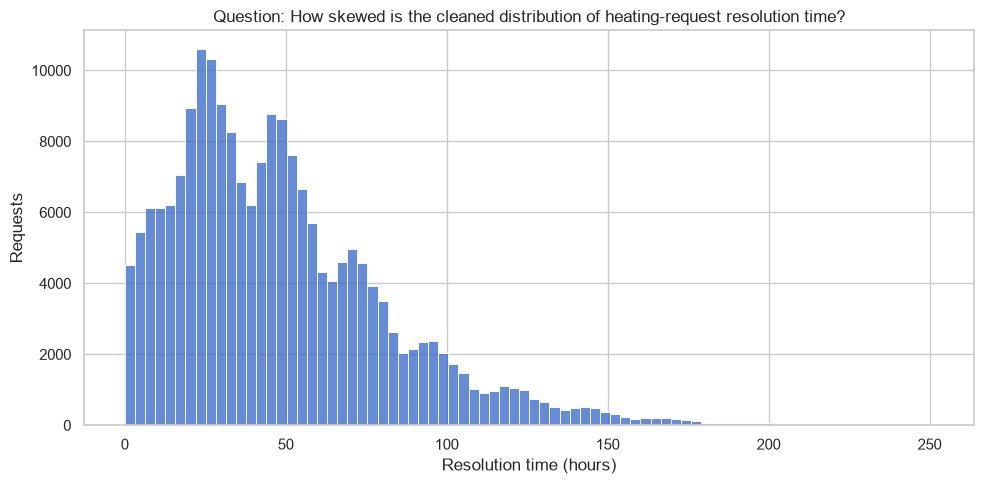

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(plot_df, x="Resolution Time", bins=80, color="#3366cc")
plt.xlabel("Resolution time (hours)")
plt.ylabel("Requests")
finish("Question: How skewed is the cleaned distribution of heating-request resolution time?")

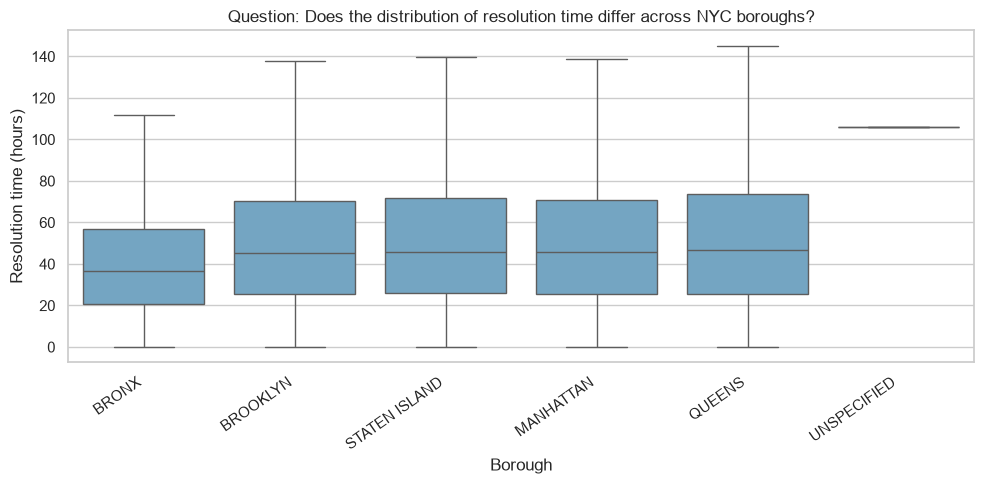

In [8]:
borough_order = (df.groupby("Borough")["Resolution Time"].median().sort_values().index)
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x="Borough", y="Resolution Time", order=borough_order,
            showfliers=False, color="#67a9cf")
plt.ylabel("Resolution time (hours)")
finish("Question: Does the distribution of resolution time differ across NYC boroughs?", rotate=True)

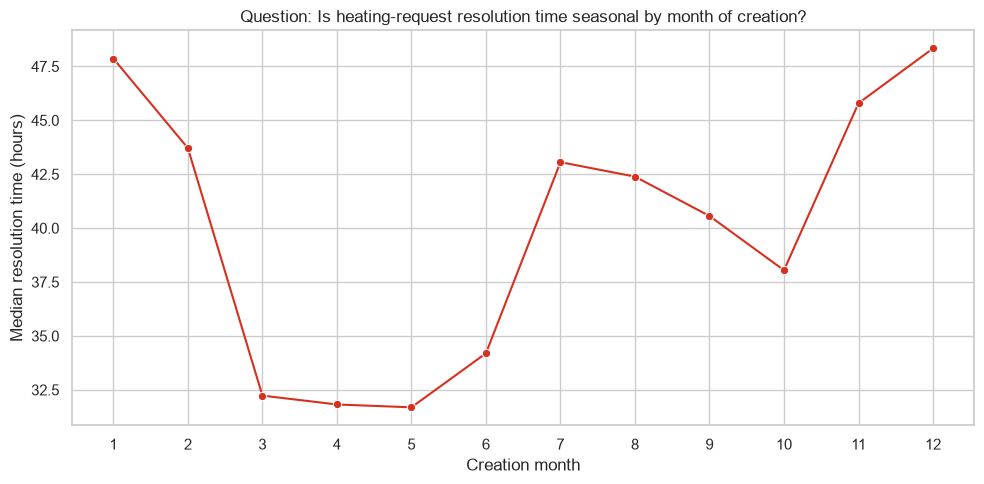

In [9]:
monthly = (df.groupby("created_month", observed=True)["Resolution Time"]
             .agg(median="median", mean="mean", requests="size").reset_index())
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=monthly, x="created_month", y="median", marker="o", ax=ax1, color="#d7301f")
ax1.set(xlabel="Creation month", ylabel="Median resolution time (hours)", xticks=range(1, 13))
finish("Question: Is heating-request resolution time seasonal by month of creation?")

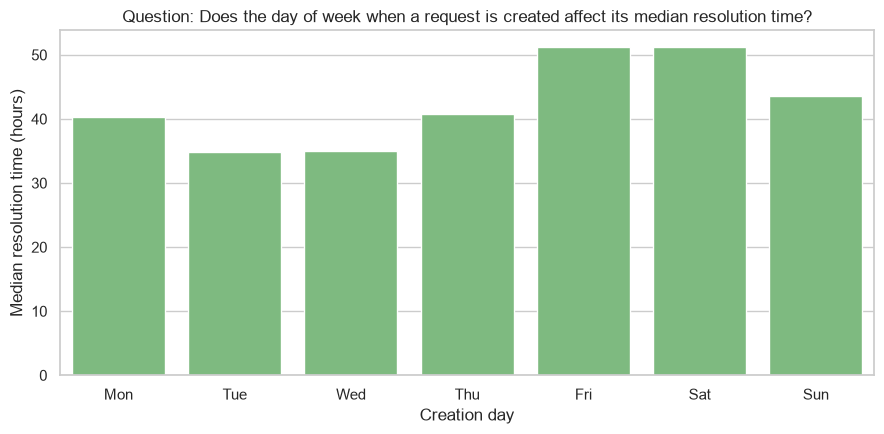

In [10]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df.groupby("created_dayofweek")["Resolution Time"].median().reindex(range(7))
plt.figure(figsize=(9, 4.5))
sns.barplot(x=dow_labels, y=dow.values, color="#74c476")
plt.xlabel("Creation day")
plt.ylabel("Median resolution time (hours)")
finish("Question: Does the day of week when a request is created affect its median resolution time?")

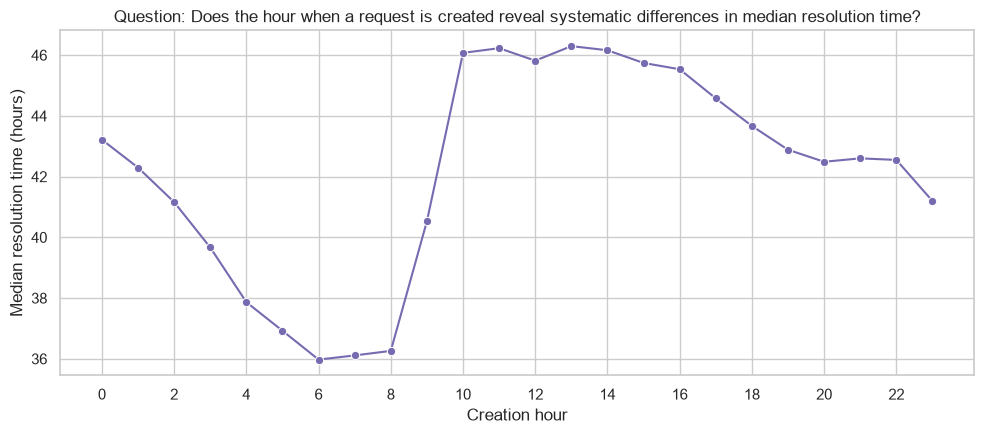

In [11]:
hourly = df.groupby("created_hour")["Resolution Time"].median().reindex(range(24))
plt.figure(figsize=(10, 4.5))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="#756bb1")
plt.xlabel("Creation hour")
plt.ylabel("Median resolution time (hours)")
plt.xticks(range(0, 24, 2))
finish("Question: Does the hour when a request is created reveal systematic differences in median resolution time?")

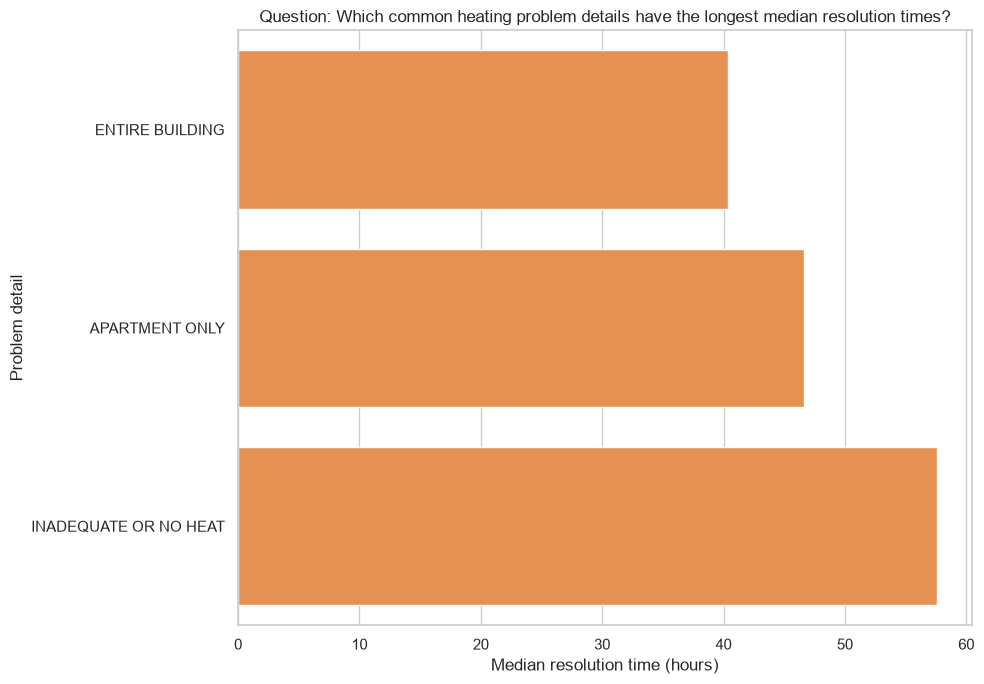

In [12]:
detail_stats = (df.groupby(DETAIL, dropna=False)["Resolution Time"]
                  .agg(median="median", requests="size")
                  .query("requests >= 100")
                  .nlargest(15, "requests")
                  .sort_values("median"))
plt.figure(figsize=(10, 7))
sns.barplot(data=detail_stats.reset_index(), x="median", y=DETAIL, color="#fd8d3c")
plt.xlabel("Median resolution time (hours)")
plt.ylabel("Problem detail")
finish("Question: Which common heating problem details have the longest median resolution times?")

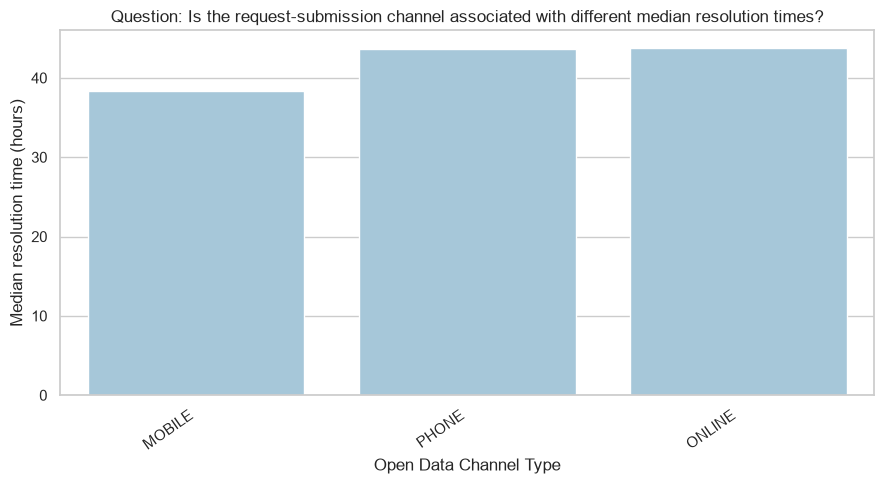

In [13]:
channel = (df.groupby("Open Data Channel Type", dropna=False)["Resolution Time"]
             .agg(median="median", requests="size").sort_values("median"))
plt.figure(figsize=(9, 5))
sns.barplot(data=channel.reset_index(), x="Open Data Channel Type", y="median", color="#9ecae1")
plt.ylabel("Median resolution time (hours)")
finish("Question: Is the request-submission channel associated with different median resolution times?", rotate=True)

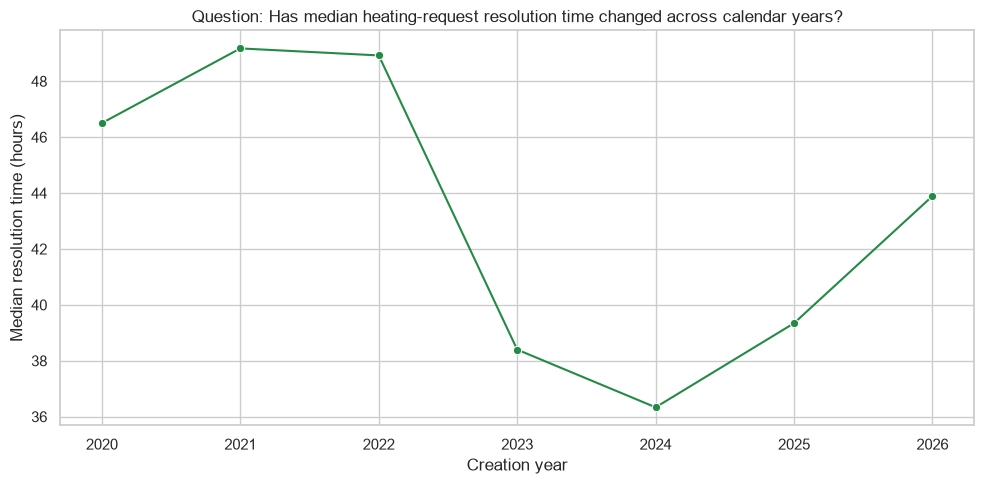

In [14]:
yearly = df.groupby("created_year")["Resolution Time"].agg(median="median", requests="size").reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly, x="created_year", y="median", marker="o", color="#238b45")
plt.xlabel("Creation year")
plt.ylabel("Median resolution time (hours)")
finish("Question: Has median heating-request resolution time changed across calendar years?")

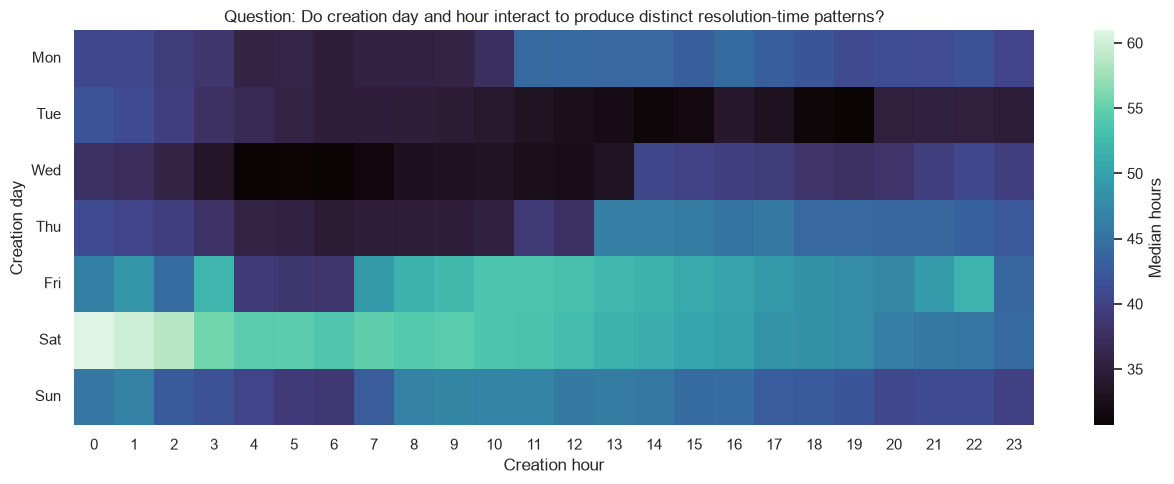

In [15]:
# Heatmap combines two creation-time factors and can reveal interactions useful to trees.
heat = df.pivot_table(index="created_dayofweek", columns="created_hour",
                      values="Resolution Time", aggfunc="median")
plt.figure(figsize=(13, 5))
sns.heatmap(heat, cmap="mako", cbar_kws={"label": "Median hours"})
plt.yticks(np.arange(7) + .5, dow_labels, rotation=0)
plt.xlabel("Creation hour")
plt.ylabel("Creation day")
finish("Question: Do creation day and hour interact to produce distinct resolution-time patterns?")

## 5. Evidence-based key insights

In [16]:
def spread_statement(feature, label):
    s = df.groupby(feature, dropna=False)["Resolution Time"].median().dropna()
    lo, hi = s.idxmin(), s.idxmax()
    return (f"**{label}:** median resolution time ranges from {s.min():,.2f} hours "
            f"({lo}) to {s.max():,.2f} hours ({hi}), a {s.max()-s.min():,.2f}-hour spread.")

target_median = df["Resolution Time"].median()
target_mean = df["Resolution Time"].mean()
insights = [
    (f"**Target shape:** mean = {target_mean:,.2f} hours and median = {target_median:,.2f} hours. "
     "Their separation and the histogram motivate MAE/median-focused evaluation and a log1p-target sensitivity analysis."),
    spread_statement("Borough", "Geography"),
    spread_statement("created_month", "Seasonality"),
    spread_statement("created_dayofweek", "Day of week"),
    spread_statement("created_hour", "Hour of day"),
    spread_statement("Open Data Channel Type", "Submission channel"),
    spread_statement(DETAIL, "Problem detail"),
]

display(Markdown("\n\n".join(f"{i+1}. {text}" for i, text in enumerate(insights))))
display(Markdown(
    "**Feature-selection consequence:** retain geography, complaint detail, channel, and cyclic/calendar variables; "
    "their group medians vary in the figures above. Use tree models to capture the day–hour and geography–season interactions. "
    "Drop post-creation fields regardless of apparent association because predictive power from leakage is invalid."
))

1. **Target shape:** mean = 48.60 hours and median = 42.78 hours. Their separation and the histogram motivate MAE/median-focused evaluation and a log1p-target sensitivity analysis.

2. **Geography:** median resolution time ranges from 36.41 hours (BRONX) to 77.93 hours (UNSPECIFIED), a 41.53-hour spread.

3. **Seasonality:** median resolution time ranges from 31.69 hours (5) to 48.33 hours (12), a 16.64-hour spread.

4. **Day of week:** median resolution time ranges from 34.84 hours (1) to 51.25 hours (5), a 16.41-hour spread.

5. **Hour of day:** median resolution time ranges from 35.97 hours (6) to 46.30 hours (13), a 10.32-hour spread.

6. **Submission channel:** median resolution time ranges from 38.39 hours (MOBILE) to 43.79 hours (ONLINE), a 5.40-hour spread.

7. **Problem detail:** median resolution time ranges from 40.40 hours (ENTIRE BUILDING) to 57.57 hours (INADEQUATE OR NO HEAT), a 17.18-hour spread.

**Feature-selection consequence:** retain geography, complaint detail, channel, and cyclic/calendar variables; their group medians vary in the figures above. Use tree models to capture the day–hour and geography–season interactions. Drop post-creation fields regardless of apparent association because predictive power from leakage is invalid.

## 6. Model-ready data and leakage-safe preprocessing

In [17]:
# Chronological 70/15/15 split by creation time.
df = df.sort_values("Created Date").reset_index(drop=True)
n = len(df)
train_end, valid_end = int(.70 * n), int(.85 * n)

train = df.iloc[:train_end].copy()
valid = df.iloc[train_end:valid_end].copy()
test = df.iloc[valid_end:].copy()

X_train, y_train = train[candidate_features], train["Resolution Time"]
X_valid, y_valid = valid[candidate_features], valid["Resolution Time"]
X_test, y_test = test[candidate_features], test["Resolution Time"]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train), len(valid), len(test)],
    "created_min": [x["Created Date"].min() for x in [train, valid, test]],
    "created_max": [x["Created Date"].max() for x in [train, valid, test]],
})
display(split_summary)

categorical_features = [
    "Agency", PROBLEM, DETAIL, "Location Type", "Incident Zip", "Address Type",
    "Community Board", "Borough", "Open Data Channel Type"
]
numeric_features = [
    "Council District", "Police Precinct", "Latitude", "Longitude", "created_year",
    "created_dayofweek", "created_hour", "created_is_weekend", "month_sin",
    "month_cos", "hour_sin", "hour_cos"
]

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.005)),
])
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),  # useful for linear models; harmless but optional for trees
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipe, categorical_features),
    ("numeric", numeric_pipe, numeric_features),
], remainder="drop")

# Intentionally not fitted here: no ML model is required. To prepare matrices later:
# X_train_ready = preprocessor.fit_transform(X_train)
# X_valid_ready = preprocessor.transform(X_valid)
# X_test_ready = preprocessor.transform(X_test)

assert set(candidate_features) == set(categorical_features + numeric_features)
assert not set(candidate_features) & set(LEAKAGE_COLUMNS)
print("Leakage audit passed; preprocessing pipeline is defined but unfitted.")

,split,rows,created_min,created_max
0,train,1145946,2020-01-01 00:04:45,2025-01-12 11:28:22
1,validation,245560,2025-01-12 11:28:27,2025-12-09 19:01:38
2,test,245561,2025-12-09 19:01:39,2026-10-01 17:53:22


Leakage audit passed; preprocessing pipeline is defined but unfitted.


## 7. Data Preparation Decision Table

In [18]:
def miss_evidence(col):
    pct = 100 * df[col].isna().mean()
    return f"{pct:.2f}% missing after validity checks; "

def median_spread(col):
    s = df.groupby(col, dropna=False)["Resolution Time"].median().dropna()
    return f"EDA median range = {s.min():,.2f}–{s.max():,.2f} hours across observed groups."

decision_rows = [
    ["Created Date", "Valid timestamp; raw value not directly model-safe", "Transform",
     "Converted to year/day/hour/weekend and cyclic month/hour features; chronological split uses the original timestamp."],
    ["Closed Date", "Post-creation timestamp; missing for open tickets", "Drop after target creation",
     f"Used once to calculate the target; {row_audit.loc[row_audit.Step.eq('Missing/invalid Closed Date'), 'Rows removed'].sum():,} open/invalid rows were removed."],
    ["Resolution Time", "Right-skewed continuous target with extreme upper tail", "Clean/target",
     f"Negative values removed; values above the 99.5th-percentile cutoff of {upper_hours:,.2f} hours removed; histogram shows skew."],
    ["Status; Due Date; Resolution Description; Resolution Action Updated Date", "Post-creation or mutable fields", "Drop",
     "Unavailable or changeable after submission, so inclusion would leak future workflow/outcome information."],
    ["Unique Key", "Identifier; one value per request", "Deduplicate then drop",
     f"Removed {row_audit.loc[row_audit.Step.eq('Duplicate Unique Key'), 'Rows removed'].sum():,} repeated keys; an ID cannot generalize."],
    ["Agency Name", "Redundant with Agency", "Drop",
     "Duplicate semantic representation adds collinearity without new creation-time information."],
    ["Incident Address; BBL", "Exact/high-cardinality location identifiers", "Drop",
     "Privacy and memorization risk; generalizable ZIP, borough, community board, coordinates, council district, and precinct are retained."],
    ["Additional Details; City; Facility Type", "Sparse, unstable, redundant, or free-text-like", "Drop",
     "Excluded to prevent fragile high-dimensional features; structured complaint, location, and geography fields provide reproducible alternatives."],
    ["Borough", "Categorical geography with missing values", "Clean + one-hot encode",
     miss_evidence("Borough") + median_spread("Borough")],
    ["Incident Zip; Community Board", "Categorical geography; missing and high-cardinality", "Clean + rare-level one-hot encode",
     f"ZIP is normalized to five digits; missing becomes MISSING; levels below 0.5% are grouped. {miss_evidence('Incident Zip')}"],
    ["Council District; Police Precinct", "Numeric-coded geography with missing values", "Numeric coercion + median impute + missing indicator",
     miss_evidence("Council District") + "Training-only median prevents using future information."],
    ["Latitude; Longitude", "Numeric coordinates with missing/invalid values", "Bound-check + median impute + missing indicator",
     miss_evidence("Latitude") + "Values outside NYC bounds are treated as missing."],
    [f"{PROBLEM}; {DETAIL}", "Creation-time categorical complaint description", "Clean + rare-level one-hot encode",
     median_spread(DETAIL) + " The detail chart supports retaining complaint semantics."],
    ["Location Type; Address Type", "Creation-time categorical context with missing values", "Clean + rare-level one-hot encode",
     miss_evidence("Location Type") + "Missing becomes an explicit category."],
    ["Open Data Channel Type", "Creation-time categorical submission channel", "Clean + one-hot encode",
     median_spread("Open Data Channel Type") + " The channel chart supports retention."],
    ["created_year", "Time trend / possible policy drift", "Derive and retain",
     median_spread("created_year") + " The yearly chart supports a temporal feature and chronological validation."],
    ["created_dayofweek; created_is_weekend", "Calendar timing", "Derive and retain",
     median_spread("created_dayofweek") + " Day/hour heatmap also indicates possible interaction."],
    ["month_sin; month_cos", "Month is cyclic", "Derive and retain",
     median_spread("created_month") + " Sine/cosine keeps December adjacent to January."],
    ["created_hour; hour_sin; hour_cos", "Hour is cyclic", "Derive and retain",
     median_spread("created_hour") + " Sine/cosine keeps 23:00 adjacent to 00:00."],
]

decision_table = pd.DataFrame(decision_rows, columns=[
    "Feature/Column Name", "Data Issue/State",
    "Action Taken (Clean/Drop/Transform)", "Because (Reasoning)"
])
display(decision_table.style.hide(axis="index"))

# Machine-readable artifacts make the exact decisions portable.
decision_table.to_csv("resolution_time_decision_table.csv", index=False)
pd.DataFrame({"feature": candidate_features}).to_csv("final_model_features.csv", index=False)

Feature/Column Name,Data Issue/State,Action Taken (Clean/Drop/Transform),Because (Reasoning)
Created Date,Valid timestamp; raw value not directly model-safe,Transform,Converted to year/day/hour/weekend and cyclic month/hour features; chronological split uses the original timestamp.
Closed Date,Post-creation timestamp; missing for open tickets,Drop after target creation,"Used once to calculate the target; 17,672 open/invalid rows were removed."
Resolution Time,Right-skewed continuous target with extreme upper tail,Clean/target,Negative values removed; values above the 99.5th-percentile cutoff of 251.40 hours removed; histogram shows skew.
Status; Due Date; Resolution Description; Resolution Action Updated Date,Post-creation or mutable fields,Drop,"Unavailable or changeable after submission, so inclusion would leak future workflow/outcome information."
Unique Key,Identifier; one value per request,Deduplicate then drop,Removed 0 repeated keys; an ID cannot generalize.
Agency Name,Redundant with Agency,Drop,Duplicate semantic representation adds collinearity without new creation-time information.
Incident Address; BBL,Exact/high-cardinality location identifiers,Drop,"Privacy and memorization risk; generalizable ZIP, borough, community board, coordinates, council district, and precinct are retained."
Additional Details; City; Facility Type,"Sparse, unstable, redundant, or free-text-like",Drop,"Excluded to prevent fragile high-dimensional features; structured complaint, location, and geography fields provide reproducible alternatives."
Borough,Categorical geography with missing values,Clean + one-hot encode,0.00% missing after validity checks; EDA median range = 36.41–77.93 hours across observed groups.
Incident Zip; Community Board,Categorical geography; missing and high-cardinality,Clean + rare-level one-hot encode,ZIP is normalized to five digits; missing becomes MISSING; levels below 0.5% are grouped. 0.01% missing after validity checks;


## 8. Future machine-learning strategy

### Recommended models

1. **Naive baselines:** median target and group-median baselines (for example borough × month). Every trained model must beat these on the chronological validation set.
2. **Elastic Net on `log1p(Resolution Time)`:** interpretable linear benchmark that handles one-hot features; it will reveal whether additive effects are adequate.
3. **HistGradientBoosting / XGBoost / LightGBM:** primary candidates because resolution time is nonlinear, interactions are plausible (as in the day–hour heatmap), missingness can matter, and calendar/geographic effects need not be additive. If external packages are disallowed, use scikit-learn's histogram gradient boosting after a compatible dense/ordinal encoding.
4. **Random Forest / Extra Trees:** useful nonlinear benchmark and permutation-importance source, though memory use can be high on millions of rows.

### Final predictors

The exact model inputs are the `candidate_features` list created above:

- **Complaint/context:** `Agency`, `Problem (formerly Complaint Type)`, `Problem Detail (formerly Descriptor)`, `Location Type`, `Address Type`, `Open Data Channel Type`.
- **Generalizable geography:** `Incident Zip`, `Community Board`, `Council District`, `Police Precinct`, `Borough`, `Latitude`, `Longitude`.
- **Creation-time calendar:** `created_year`, `created_dayofweek`, `created_hour`, `created_is_weekend`, `month_sin`, `month_cos`, `hour_sin`, `hour_cos`.

### Evaluation design

- Fit every imputer/encoder/model on `X_train` only; tune on `X_valid`; touch `X_test` once.
- Primary metric: **MAE in hours**, which is easy to explain and robust to the remaining skew.
- Secondary metrics: median absolute error, RMSE (large-delay penalty), and $R^2$.
- Report metrics by borough, year, and problem detail to detect uneven errors.
- Compare modeling the raw target with `log1p` target transformation; invert with `expm1` before hour-scale metrics.
- Use permutation importance or SHAP on a held-out sample, never in-sample impurity importance alone.
- Monitor drift in complaint mix, seasonal severity, and yearly operations before deployment.

**Final conclusion:** the dataset is now specified for leakage-safe regression. Whether creation-time information is *sufficient* is an empirical question to answer by comparing the chronological test performance against the median and group-median baselines.